# Modèle 1 — Prédiction de Retard

Entraîne et sauvegarde trois modèles complémentaires :

| modèle | rôle | sortie |
|--------|------|--------|
| **HistGBM** | prédit le retard au prochain arrêt | `delay_model.pkl` |
| **LSTM Retard** | même tâche mais voit l'historique du trajet | `delay_lstm.pt` |
| **Prophet** | prévision du retard moyen journalier par ligne | `prophet_{line}_{dir}.pkl` |

Modifiez le bloc **Config** puis relancez tout (`Kernel → Restart & Run All`).

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pickle
from sklearn.metrics import mean_absolute_error
from IPython.display import display

from src.data import delay as dl

print('imports OK')

imports OK


In [26]:
# Config 
MIN_OBS       = 20      # observations minimales pour la référence de base
TRAIN_RATIO   = 0.80    # fraction des jours pour l'entraînement (coupure temporelle)

# HistGBM
HGBM_MAX_ITER = 300     # arbres (augmenter → meilleur ajustement, plus lent)
HGBM_LR       = 0.05   # taux d'apprentissage
HGBM_MAX_LEAF = 31      # feuilles max par arbre

# LSTM Retard
LSTM_HIDDEN   = 64      # neurones cachés par couche
LSTM_LAYERS   = 2       # couches LSTM empilées
LSTM_EPOCHS   = 10      # augmenter à 30-50 pour de meilleures performances
LSTM_LR       = 1e-3
LSTM_BATCH    = 256
LSTM_MAXLEN   = 30      # arrêts par séquence (complété/tronqué)

# Prophet
PROPHET_LINE    = '209'
PROPHET_DIR     = 'ALLER'
PROPHET_SOCIETE = 'S.R.T.K'
PROPHET_PERIODS = 30    # jours à prévoir

# Chemins
ROOT       = Path.cwd().parents[1]
FOUNDATION = ROOT / 'data' / 'processed' / 'foundation_arrivals_full.parquet'
MODELS_DIR = ROOT / 'models' / 'delay'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'foundation : {FOUNDATION.name}  existe={FOUNDATION.exists()}')
print(f'modèles sauvegardés dans : {MODELS_DIR}')

foundation : foundation_arrivals_full.parquet  existe=True
modèles sauvegardés dans : c:\Users\deadx\OneDrive\Desktop\winicari\models\delay


In [3]:
# Charger les données de fondation
CFG = dl.DelayConfig(min_obs=MIN_OBS)
df  = dl.load_foundation(FOUNDATION)

print(f'lignes : {len(df):,} | lignes bus : {df["line"].nunique()} | '
      f'compagnies : {df["societe"].nunique()}')
print(f'plage de dates : {df["day"].min()} → {df["day"].max()}')
display(df.head(3))

lignes : 168,481 | lignes bus : 29 | compagnies : 3
plage de dates : 20250101 → 20260621


,day,line,societe,bus,trip_id,dir,full,trip_start,trip_end,seq,route_seq,stop,arrival,departure,dwell_s,dist_m,matched
0,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,0,0,KASSERINE,2025-01-01 03:01:22.300,2025-01-01 03:04:52.262,210.0,92.0,True
1,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,1,1,BOUZGUEM,2025-01-01 03:14:07.268,2025-01-01 03:14:37.281,30.0,46.0,True
2,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,2,2,EL GARRAA,NaT,NaT,NaN,1238.0,False


In [4]:
# Ajouter les caractéristiques temporelles (temps écoulé + type de jour)
m = dl.add_daytype(dl.with_elapsed(df, CFG))

print(f'arrivées correspondantes avec temps écoulé : {len(m):,}')
print(f'colonnes ajoutées : elapsed_min, dep_hour, is_weekend')
display(m[['day','line','dir','seq','stop','elapsed_min','dep_hour','is_weekend']].head(5))

arrivées correspondantes avec temps écoulé : 128,882
colonnes ajoutées : elapsed_min, dep_hour, is_weekend


,day,line,dir,seq,stop,elapsed_min,dep_hour,is_weekend
0,20250101,217,ALLER,0,KASSERINE,0.500017,3,0
1,20250101,217,ALLER,1,BOUZGUEM,13.249483,3,0
2,20250101,217,ALLER,3,CHRAYA,23.150600,3,0
3,20250101,217,ALLER,4,SBEITLA,38.532983,3,0
4,20250101,217,ALLER,5,M'GHILLA,57.032967,3,0


In [5]:
# Construire la référence « horaire » basée sur les données
baseline = dl.build_baseline(m, CFG)

print(f'cellules de référence (≥{MIN_OBS} trajets) : {len(baseline):,}')
print(f'lignes couvertes : {baseline["line"].nunique()}')
display(baseline.head(5))

cellules de référence (≥20 trajets) : 549
lignes couvertes : 16


,societe,line,dir,seq,expected_min,p10,p90,n
0,S.R.T.K,202,ALLER,1,16.812133,4.840260,33.768470,67
1,S.R.T.K,202,ALLER,2,20.495700,8.337225,37.261742,68
2,S.R.T.K,202,ALLER,3,31.083133,15.000478,49.016578,68
3,S.R.T.K,202,ALLER,4,49.095450,27.995980,79.367343,77
4,S.R.T.K,202,ALLER,5,55.326683,33.002650,83.989217,81


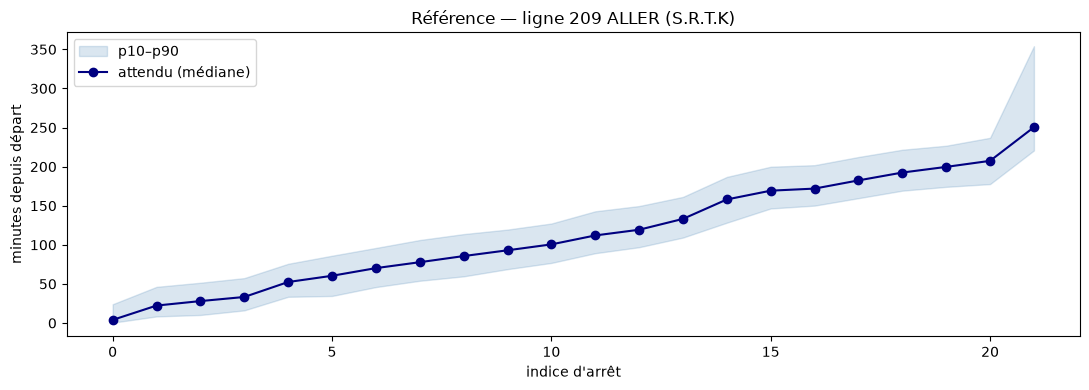

In [6]:
# Visualiser la référence pour une ligne exemple
SOC, LINE, DIR = PROPHET_SOCIETE, PROPHET_LINE, PROPHET_DIR
b = baseline[(baseline.societe==SOC) & (baseline.line==LINE) & (baseline.dir==DIR)].sort_values('seq')

plt.figure(figsize=(11, 4))
plt.fill_between(b['seq'], b['p10'], b['p90'], alpha=0.2, color='steelblue', label='p10–p90')
plt.plot(b['seq'], b['expected_min'], 'o-', color='navy', label='attendu (médiane)')
plt.xlabel("indice d'arrêt"); plt.ylabel('minutes depuis départ')
plt.title(f'Référence — ligne {LINE} {DIR} ({SOC})')
plt.legend(); plt.tight_layout(); plt.show()

In [7]:
# Calculer le retard (réel − attendu)
d = dl.add_daytype(dl.with_delay(m, baseline, CFG))

print(f'lignes avec retard : {len(d):,}')
print(d['delay_min'].describe()[['mean','std','min','25%','50%','75%','max']].round(2).to_string())

lignes avec retard : 126,914
mean      1.72
std      21.57
min    -120.00
25%      -4.92
50%       0.00
75%       6.50
max     120.00


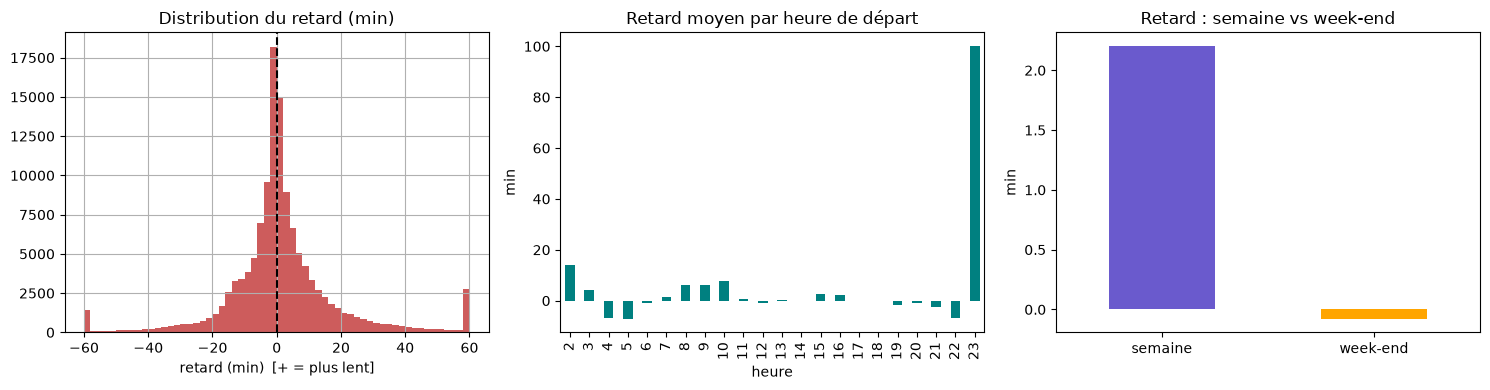

In [8]:
# Distribution du retard par heure et type de jour
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
d['delay_min'].clip(-60,60).hist(bins=60, ax=ax[0], color='indianred')
ax[0].axvline(0, color='black', ls='--')
ax[0].set_title('Distribution du retard (min)')
ax[0].set_xlabel('retard (min)  [+ = plus lent]')

d.groupby('dep_hour')['delay_min'].mean().plot(kind='bar', ax=ax[1], color='teal')
ax[1].set_title('Retard moyen par heure de départ')
ax[1].set_xlabel('heure'); ax[1].set_ylabel('min')

wk = d.groupby('is_weekend')['delay_min'].mean()
wk.index = ['semaine','week-end']
wk.plot(kind='bar', ax=ax[2], color=['slateblue','orange'])
ax[2].set_title('Retard : semaine vs week-end')
ax[2].set_ylabel('min'); ax[2].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

In [9]:
# Table glissante + coupure train/test
roll = dl.rolling_table(d)
days = np.sort(roll['day'].unique())
cut  = days[int(TRAIN_RATIO * len(days))]
tr   = roll[roll['day'] <  cut]
te   = roll[roll['day'] >= cut]

print(f'échantillons — train : {len(tr):,}  test : {len(te):,}  (test à partir du jour {cut})')
print(f'caractéristiques : {dl._design(tr).columns.tolist()}')

échantillons — train : 95,225  test : 12,009  (test à partir du jour 20260302)
caractéristiques : ['dep_hour', 'dow', 'is_weekend', 'seq', 'seq_frac', 'delay_min', 'elapsed_min', 'line', 'dir']


In [10]:
# Entraîner HistGBM
from sklearn.ensemble import HistGradientBoostingRegressor

model = dl.train_rolling_model(
    tr,
    max_iter=HGBM_MAX_ITER,
    learning_rate=HGBM_LR,
    max_leaf_nodes=HGBM_MAX_LEAF,
)
print('HistGBM entraîné ✓')
print(f'  paramètres : max_iter={HGBM_MAX_ITER}, lr={HGBM_LR}, max_leaf={HGBM_MAX_LEAF}')

HistGBM entraîné ✓
  paramètres : max_iter=300, lr=0.05, max_leaf=31


In [ ]:
# Grid Search — HistGBM
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.stats import randint, loguniform
import warnings

param_dist = {
    'max_iter':         randint(100, 500),
    'learning_rate':    loguniform(0.005, 0.15),
    'max_depth':        randint(3, 10),
    'min_samples_leaf': randint(5, 60),
    'max_leaf_nodes':   randint(15, 127),
}

tscv = TimeSeriesSplit(n_splits=3)

gs_hgbm = RandomizedSearchCV(
    HistGradientBoostingRegressor(
        categorical_features=dl.FEATURES_CAT,
        random_state=0,
    ),
    param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2,
    random_state=42,
    refit=True,
)

print('Fitting 20 HistGBM configs × 3 TimeSeriesSplit folds ...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    gs_hgbm.fit(dl._design(tr), tr[dl.TARGET])

print(f'\nBest params : {gs_hgbm.best_params_}')
print(f'Best CV MAE : {-gs_hgbm.best_score_:.3f} min')

# Show top-5 configs
cv_res = pd.DataFrame(gs_hgbm.cv_results_)
top5 = (cv_res[['param_max_iter', 'param_learning_rate', 'param_max_depth',
                 'param_min_samples_leaf', 'param_max_leaf_nodes', 'mean_test_score']]
        .sort_values('mean_test_score', ascending=False)
        .head(5)
        .copy())
top5['mean_test_score'] = -top5['mean_test_score']
top5.columns = [c.replace('param_', '') for c in top5.columns]
print('\nTop-5 configs (MAE ↓ = better):')
display(top5.reset_index(drop=True))

# Update model with best estimator
model = gs_hgbm.best_estimator_
print('\nmodel updated ✓  (best HistGBM from RandomizedSearchCV)')

Fitting 20 HistGBM configs × 3 TimeSeriesSplit folds ...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params : {'learning_rate': np.float64(0.03210165168148931), 'max_depth': 8, 'max_iter': 290, 'max_leaf_nodes': 32, 'min_samples_leaf': 30}
Best CV MAE : 2.778 min

Top-5 configs (MAE ↓ = better):


,max_iter,learning_rate,max_depth,min_samples_leaf,max_leaf_nodes,mean_test_score
0,290,0.032102,8,30,32,2.778204
1,113,0.126063,6,30,23,2.780566
2,357,0.045752,7,48,102,2.798493
3,428,0.039481,7,22,53,2.809288
4,437,0.088399,7,57,125,2.809583



model updated ✓  (best HistGBM from RandomizedSearchCV)


In [13]:
# Évaluer HistGBM vs références
pred_hgbm = model.predict(dl._design(te))

mae_hgbm  = mean_absolute_error(te[dl.TARGET], pred_hgbm)
mae_pers  = mean_absolute_error(te[dl.TARGET], te['delay_min'])
mae_naive = mean_absolute_error(te[dl.TARGET], np.zeros(len(te)))

print('─' * 40)
print(f'  HistGBM      MAE : {mae_hgbm:.2f} min')
print(f'  Persistance  MAE : {mae_pers:.2f} min  (retard suivant = actuel)')
print(f"  Naïf zéro    MAE : {mae_naive:.2f} min  (toujours à l'heure)")
print('─' * 40)
print(f'  Gain vs persistance : {mae_pers - mae_hgbm:.2f} min')

────────────────────────────────────────
  HistGBM      MAE : 2.77 min
  Persistance  MAE : 3.06 min  (retard suivant = actuel)
  Naïf zéro    MAE : 13.76 min  (toujours à l'heure)
────────────────────────────────────────
  Gain vs persistance : 0.29 min


C:\Users\deadx\AppData\Local\Temp\ipykernel_3612\3351903212.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  te2.groupby('dep_hour').apply(lambda x: mean_absolute_error(x[dl.TARGET], x['pred'])).plot(
C:\Users\deadx\AppData\Local\Temp\ipykernel_3612\3351903212.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  worst = (te2.groupby('line').apply(lambda x: mean_absolute_error(x[dl.TARGET], x['pred']))


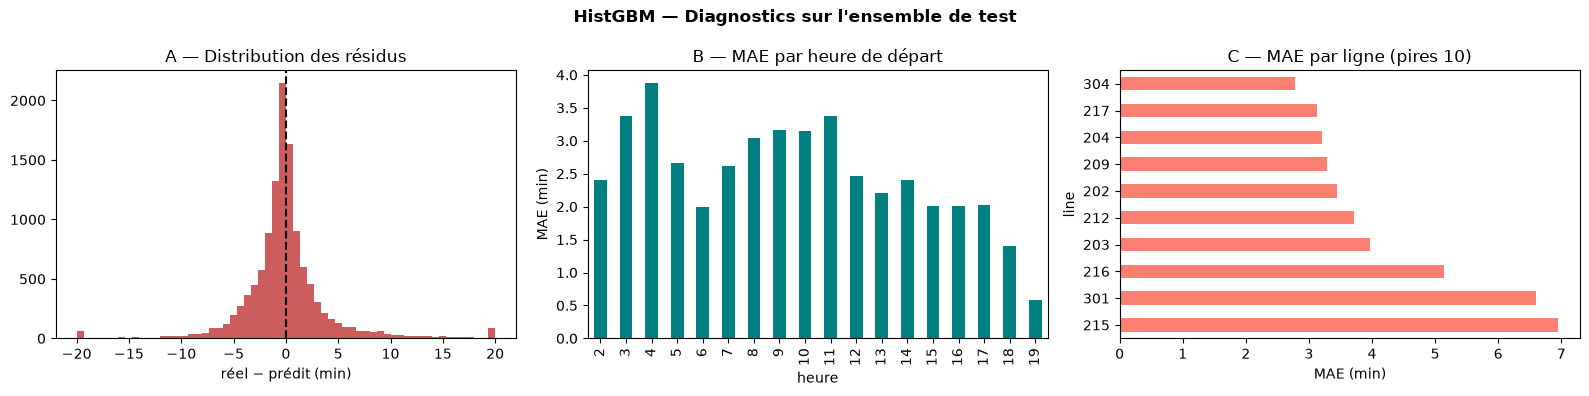

In [15]:
# Diagnostics : résidus, MAE par heure, MAE par ligne
te2 = te.copy(); te2['pred'] = pred_hgbm; te2['err'] = te2[dl.TARGET] - te2['pred']

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("HistGBM — Diagnostics sur l'ensemble de test", fontweight='bold')

ax[0].hist(te2['err'].clip(-20,20), bins=60, color='indianred')
ax[0].axvline(0, color='black', ls='--')
ax[0].set_title('A — Distribution des résidus')
ax[0].set_xlabel('réel − prédit (min)')

te2.groupby('dep_hour').apply(lambda x: mean_absolute_error(x[dl.TARGET], x['pred'])).plot(
    kind='bar', ax=ax[1], color='teal')
ax[1].set_title('B — MAE par heure de départ')
ax[1].set_xlabel('heure'); ax[1].set_ylabel('MAE (min)')

worst = (te2.groupby('line').apply(lambda x: mean_absolute_error(x[dl.TARGET], x['pred']))
           .sort_values(ascending=False).head(10))
worst.plot(kind='barh', ax=ax[2], color='salmon')
ax[2].set_title('C — MAE par ligne (pires 10)')
ax[2].set_xlabel('MAE (min)')
plt.tight_layout(); plt.show()

,seq,expected_min,pred_delay_min,eta
0,6,70.2,8.1,07:18
1,7,77.8,8.2,07:25
2,8,85.6,8.2,07:33
3,9,93.0,8.2,07:41
4,10,100.5,8.2,07:48
5,11,112.0,8.2,08:00
6,12,119.3,8.2,08:07
7,13,133.2,7.6,08:20
8,14,158.0,7.6,08:45
9,15,169.3,7.8,08:57


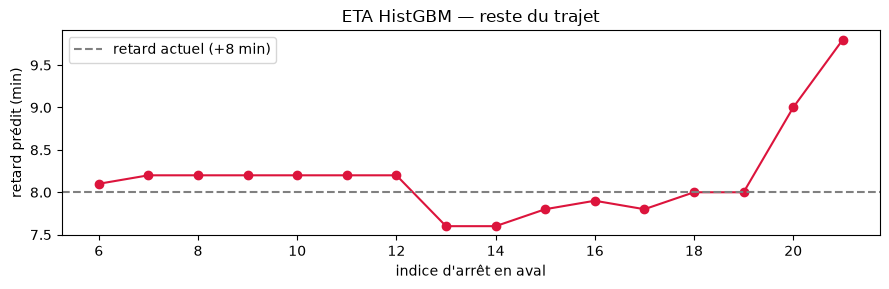

In [16]:
# Démonstration ETA : bus ligne 209, arrêt 5, +8 min de retard
eta = dl.serve_eta(model, baseline,
                   societe=PROPHET_SOCIETE, line=PROPHET_LINE, direction=PROPHET_DIR,
                   dep_time='2026-06-15 06:00:00', current_seq=5, current_delay_min=8.0)
display(eta.assign(eta=eta['eta'].dt.strftime('%H:%M')).head(12))

plt.figure(figsize=(9, 3))
plt.plot(eta['seq'], eta['pred_delay_min'], 'o-', color='crimson')
plt.axhline(8.0, color='grey', ls='--', label='retard actuel (+8 min)')
plt.xlabel("indice d'arrêt en aval"); plt.ylabel('retard prédit (min)')
plt.title('ETA HistGBM — reste du trajet'); plt.legend()
plt.tight_layout(); plt.show()

## LSTM Retard

Le LSTM voit l'**historique complet** des retards du trajet, pas seulement l'état actuel.
Utile sur les longues lignes où le retard s'accumule de façon prévisible.

In [17]:
# Construire les tenseurs de séquences
X, lengths, y = dl.build_lstm_sequences(roll, max_len=LSTM_MAXLEN)
train_mask = roll['day'] < cut
te_mask    = roll['day'] >= cut

X_tr, y_tr = X[train_mask.values], y[train_mask.values]
X_te, y_te = X[te_mask.values],    y[te_mask.values]
print(f'tenseur X : {X.shape}   (trajets × arrêts × caractéristiques)')
print(f'train : {len(X_tr):,}   test : {len(X_te):,}')

tenseur X : (107234, 30, 5)   (trajets × arrêts × caractéristiques)
train : 95,225   test : 12,009


In [18]:
# Entraîner le LSTM
lstm_delay = dl.train_lstm_delay(
    X_tr, y_tr,
    hidden=LSTM_HIDDEN, n_layers=LSTM_LAYERS,
    epochs=LSTM_EPOCHS, lr=LSTM_LR, batch=LSTM_BATCH,
)
print(f'LSTM entraîné ✓  (hidden={LSTM_HIDDEN}, layers={LSTM_LAYERS}, epochs={LSTM_EPOCHS})')

  époque   5/10  train=73.8918  val=93.5252
  époque  10/10  train=45.8157  val=66.3172
LSTM entraîné ✓  (hidden=64, layers=2, epochs=10)


In [ ]:
# Grid Search — LSTM Retard 
import itertools

lstm_gs_grid = {
    'hidden':   [32, 64, 128],
    'n_layers': [1, 2],
    'lr':       [5e-4, 1e-3],
}

lstm_gs_results = []
combos_lstm = list(itertools.product(
    lstm_gs_grid['hidden'],
    lstm_gs_grid['n_layers'],
    lstm_gs_grid['lr'],
))
print(f'Testing {len(combos_lstm)} LSTM configs '
      f'({len(lstm_gs_grid["hidden"])} hidden × '
      f'{len(lstm_gs_grid["n_layers"])} layers × '
      f'{len(lstm_gs_grid["lr"])} lr) ...\n')

for hidden, n_layers, lr in combos_lstm:
    m = dl.train_lstm_delay(
        X_tr, y_tr,
        hidden=hidden, n_layers=n_layers,
        epochs=20, lr=lr, batch=LSTM_BATCH,
    )
    preds   = dl.predict_lstm(m, X_te)
    cur_mae = mean_absolute_error(y_te, preds)
    lstm_gs_results.append({
        'hidden': hidden, 'n_layers': n_layers, 'lr': lr,
        'mae': cur_mae, 'model': m,
    })
    print(f'  hidden={hidden:3d}  layers={n_layers}  lr={lr:.0e}  →  MAE={cur_mae:.3f} min')

lstm_gs_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'}
                             for r in lstm_gs_results])
lstm_gs_df_sorted = lstm_gs_df.sort_values('mae')
print('\nTop-5 LSTM configs (MAE ↓ = better):')
display(lstm_gs_df_sorted.head(5).reset_index(drop=True))

best_lstm_idx = lstm_gs_df['mae'].idxmin()
best_lstm_row = lstm_gs_df.iloc[best_lstm_idx]
print(f'\nBest LSTM: hidden={int(best_lstm_row.hidden)}, '
      f'layers={int(best_lstm_row.n_layers)}, lr={best_lstm_row.lr:.0e}  '
      f'→  MAE={best_lstm_row.mae:.3f} min')

# Update lstm_delay so the downstream comparison cell uses the best model
lstm_delay = lstm_gs_results[best_lstm_idx]['model']
print('lstm_delay updated ✓  (best LSTM from grid search)')

Testing 12 LSTM configs (3 hidden × 2 layers × 2 lr) ...



c:\Users\deadx\anaconda3\envs\bus-intelligence\Lib\site-packages\torch\nn\modules\rnn.py:1009: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


  époque   5/20  train=224.1968  val=271.4539
  époque  10/20  train=145.2715  val=180.8615
  époque  15/20  train=100.7798  val=130.3973
  époque  20/20  train=73.8582  val=100.2039
  hidden= 32  layers=1  lr=5e-04  →  MAE=3.735 min


c:\Users\deadx\anaconda3\envs\bus-intelligence\Lib\site-packages\torch\nn\modules\rnn.py:1009: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


  époque   5/20  train=181.3103  val=219.8063
  époque  10/20  train=104.0776  val=134.6033
  époque  15/20  train=67.4961  val=94.5757
  époque  20/20  train=51.3595  val=75.5204
  hidden= 32  layers=1  lr=1e-03  →  MAE=3.590 min
  époque   5/20  train=195.8006  val=233.1447
  époque  10/20  train=119.1051  val=147.1572
  époque  15/20  train=80.4449  val=104.2748
  époque  20/20  train=59.7915  val=81.1988
  hidden= 32  layers=2  lr=5e-04  →  MAE=3.506 min
  époque   5/20  train=129.4446  val=153.6716
  époque  10/20  train=69.3987  val=91.7712
  époque  15/20  train=50.2147  val=67.5466
  époque  20/20  train=43.3324  val=60.5326
  hidden= 32  layers=2  lr=1e-03  →  MAE=3.414 min


...

  époque   5/20  train=91.8908  val=114.4525
  époque  10/20  train=49.9018  val=70.1800
  époque  15/20  train=40.7438  val=58.4644
  époque  20/20  train=38.3333  val=55.2782
  hidden=128  layers=1  lr=5e-04  →  MAE=3.089 min


c:\Users\deadx\anaconda3\envs\bus-intelligence\Lib\site-packages\torch\nn\modules\rnn.py:1009: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


  époque   5/20  train=52.8844  val=70.8892
  époque  10/20  train=40.3918  val=56.9132
  époque  15/20  train=38.2499  val=55.7323
  Arrêt anticipé à l'époque 17  (meilleure val=55.3647)
  hidden=128  layers=1  lr=1e-03  →  MAE=3.072 min
  époque   5/20  train=70.5880  val=89.8540
  époque  10/20  train=43.9049  val=60.5896
  époque  15/20  train=39.3548  val=56.4122
  époque  20/20  train=38.2556  val=55.3746
  hidden=128  layers=2  lr=5e-04  →  MAE=3.166 min
  époque   5/20  train=48.3318  val=64.7859
  époque  10/20  train=40.3111  val=56.6067
  époque  15/20  train=38.8325  val=56.4137
  Arrêt anticipé à l'époque 16  (meilleure val=54.9371)
  hidden=128  layers=2  lr=1e-03  →  MAE=3.179 min

Top-5 LSTM configs (MAE ↓ = better):


,hidden,n_layers,lr,mae
0,64,2,0.0010,3.071666
1,128,1,0.0010,3.072016
2,128,1,0.0005,3.088506
3,64,2,0.0005,3.122358
4,64,1,0.0010,3.165624



Best LSTM: hidden=64, layers=2, lr=1e-03  →  MAE=3.072 min
lstm_delay updated ✓  (best LSTM from grid search)


──────────────────────────────────────────
  LSTM         MAE : 3.07 min
  HistGBM      MAE : 2.77 min
  Persistance  MAE : 3.06 min
  Naïf zéro    MAE : 13.76 min
──────────────────────────────────────────
  → Meilleur modèle : HistGBM


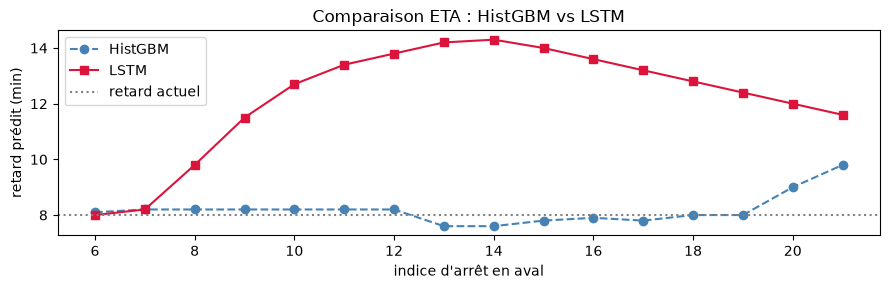

In [20]:
# Comparer LSTM vs HistGBM
pred_lstm = dl.predict_lstm(lstm_delay, X_te)

mae_lstm = mean_absolute_error(y_te, pred_lstm)
print('─' * 42)
print(f'  LSTM         MAE : {mae_lstm:.2f} min')
print(f'  HistGBM      MAE : {mae_hgbm:.2f} min')
print(f'  Persistance  MAE : {mae_pers:.2f} min')
print(f'  Naïf zéro    MAE : {mae_naive:.2f} min')
print('─' * 42)
winner = 'LSTM' if mae_lstm < mae_hgbm else 'HistGBM'
print(f'  → Meilleur modèle : {winner}')

# ETA côte à côte
eta_lstm = dl.serve_eta_lstm(lstm_delay, baseline,
                             societe=PROPHET_SOCIETE, line=PROPHET_LINE, direction=PROPHET_DIR,
                             dep_time='2026-06-15 06:00:00', current_seq=5, current_delay_min=8.0)
plt.figure(figsize=(9, 3))
plt.plot(eta['seq'],      eta['pred_delay_min'],      'o--', color='steelblue', label='HistGBM')
plt.plot(eta_lstm['seq'], eta_lstm['pred_delay_min'], 's-',  color='crimson',   label='LSTM')
plt.axhline(8.0, color='grey', ls=':', label='retard actuel')
plt.xlabel("indice d'arrêt en aval"); plt.ylabel('retard prédit (min)')
plt.title('Comparaison ETA : HistGBM vs LSTM'); plt.legend()
plt.tight_layout(); plt.show()

## Prophet — Prévision journalière

Prédit le **retard moyen attendu** pour une ligne sur les jours futurs.
Capture la saisonnalité hebdomadaire (ex. lundis plus chargés).

In [21]:
# Ajuster Prophet sur une ligne
prophet_model = dl.fit_prophet(d, line=PROPHET_LINE, direction=PROPHET_DIR, societe=PROPHET_SOCIETE)
if prophet_model:
    fc = dl.prophet_forecast(prophet_model, periods=PROPHET_PERIODS)
    print(f'Prophet ajusté ✓   prévision sur {PROPHET_PERIODS} jours')
    display(fc.assign(ds=fc['ds'].dt.strftime('%Y-%m-%d')).head(10))
else:
    print('Pas assez de données — essayer une autre ligne/direction.')

10:40:39 - cmdstanpy - INFO - Chain [1] start processing
10:40:39 - cmdstanpy - INFO - Chain [1] done processing


Prophet ajusté ✓   prévision sur 30 jours


,ds,yhat,yhat_lower,yhat_upper
0,2026-06-19,13.858411,-21.604858,47.771869
1,2026-06-20,6.413005,-28.242882,39.316034
2,2026-06-21,-9.889882,-42.410433,23.199606
3,2026-06-22,14.949966,-17.378548,50.226503
4,2026-06-23,14.229044,-19.560603,48.370918
5,2026-06-24,5.613114,-30.291263,39.904361
6,2026-06-25,0.002269,-33.766234,34.283522
7,2026-06-26,14.074203,-20.458517,50.346302
8,2026-06-27,6.628797,-26.557669,41.355940
9,2026-06-28,-9.674090,-41.638237,24.016957


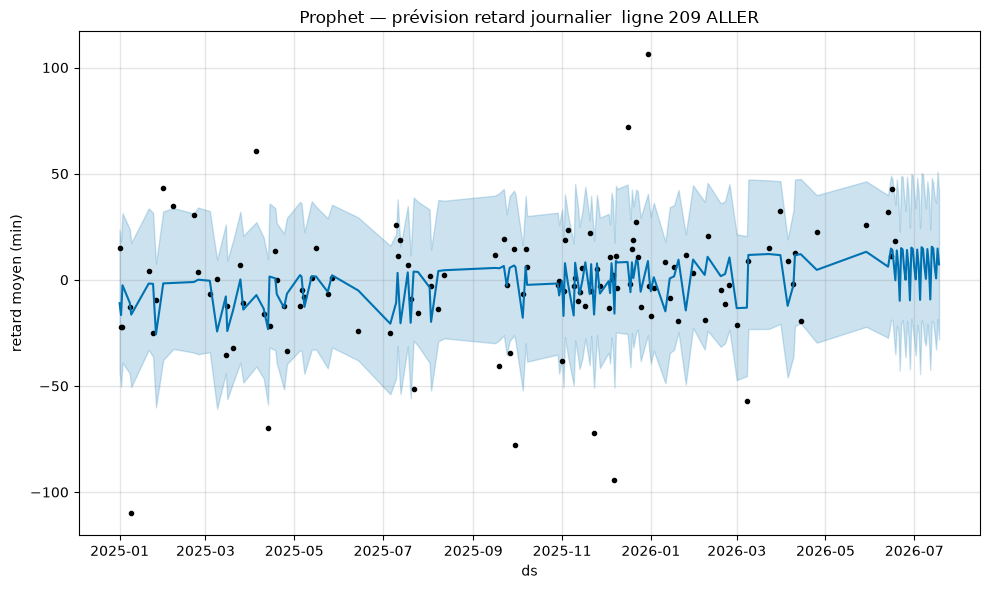

In [22]:
# Graphique de prévision Prophet
if prophet_model:
    future = prophet_model.make_future_dataframe(periods=PROPHET_PERIODS)
    fig = prophet_model.plot(prophet_model.predict(future))
    fig.axes[0].set_title(f'Prophet — prévision retard journalier  ligne {PROPHET_LINE} {PROPHET_DIR}')
    fig.axes[0].set_ylabel('retard moyen (min)')
    plt.tight_layout(); plt.show()

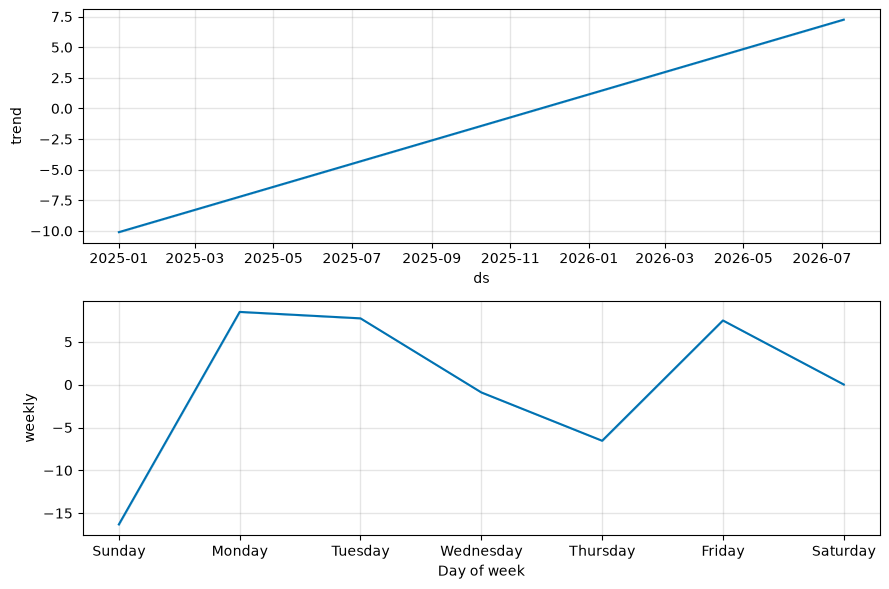

In [23]:
# Composantes saisonnières Prophet
if prophet_model:
    fig = prophet_model.plot_components(prophet_model.predict(future))
    plt.tight_layout(); plt.show()

In [27]:
# Sauvegarder tous les modèles
import torch

joblib.dump(model, MODELS_DIR / 'delay_hgbm.pkl')
print(f'✓  delay_hgbm.pkl')

torch.save(lstm_delay.state_dict(), MODELS_DIR / 'delay_lstm.pt')
print(f'✓  delay_lstm.pt')

joblib.dump(baseline, MODELS_DIR / 'delay_baseline.pkl')
print(f'✓  delay_baseline.pkl')

if prophet_model:
    with open(MODELS_DIR / f'prophet_{PROPHET_LINE}_{PROPHET_DIR}.pkl', 'wb') as f:
        pickle.dump(prophet_model, f)
    print(f'✓  prophet_{PROPHET_LINE}_{PROPHET_DIR}.pkl')

print(f'\nTous les modèles sauvegardés dans : {MODELS_DIR}')

✓  delay_hgbm.pkl
✓  delay_lstm.pt
✓  delay_baseline.pkl
✓  prophet_209_ALLER.pkl

Tous les modèles sauvegardés dans : c:\Users\deadx\OneDrive\Desktop\winicari\models\delay
